In [ ]:
!pip install transformers
!pip install datasets evaluate sentence_transformers
!pip install torchmetrics

In [4]:
from transformers import pipeline
import pandas as pd

import os
import subprocess

import numpy as np

from random import sample
from IPython.display import clear_output
from tqdm import tqdm

import torch
from torch import nn
from torch.optim import AdamW
from torch.utils.data import DataLoader
from torchmetrics.functional import accuracy

from peft import get_peft_model, LoraConfig, TaskType
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import get_scheduler

import matplotlib.pyplot as plt
import seaborn as sns

import evaluate
from datasets import load_dataset

from tqdm import tqdm

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
    roc_auc_score, average_precision_score
)

sns.set_theme()

Загрузим датасет с HF на русском языке. Данные представляют из себя размеченный список из +- 6500 комментариев из соц сетей с тегами токсичности. Комментарии на соверщенно разные темы от спорта и до политики

In [5]:
dataset = load_dataset("s-nlp/ru_paradetox_toxicity")
dataset["train"][100]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


{'neutral': 'покусала и спряталась.... :(', 'toxic': False}

In [6]:
dataset["train"][:10]

{'neutral': ['Вот и довели себя до сахарного диабета второго типа',
  'Мойщик машину пеной залил, а хозяин виноват? По-моему ты ошибаешься.',
  'Какой совет может дать эта девушка?',
  'Зачем брать топор и убивать то?',
  'Такой же как и Дегтярев. Другими словами оба ребята из песочницы, которую построил пу',
  'Зачем брать топор и убивать то',
  'Не ходи без перчаток',
  'он вас трогал ?',
  'Низкий поступок, бить из подтишька.',
  'Что-то не похож. Хорошо если это он, А если нет, то тот человек будет дальше нарушать закон'],
 'toxic': [False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False]}

In [ ]:
clf = pipeline(
    task = 'sentiment-analysis',
    model = 's-nlp/russian_toxicity_classifier')

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/711M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/585 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Device set to use cuda:0


Теперь выполним классификацию дефолтной моделью с HF, в описании которой написано, что она может быть использована для решения именно задачи классификации текстов на русском на предмет токчисности в них

In [ ]:
text = list(dataset["train"]['neutral'])

results = []
for single_text in tqdm(text, desc="Processing texts"):
    result = clf(single_text)
    results.append(result[0])

Processing texts: 100%|██████████| 6354/6354 [02:14<00:00, 47.24it/s] 


Заменим все метки на 0/1 где 0 - добрый коммент, а 1 - токсичный

In [ ]:
tags = list(dataset["train"]['toxic'])

predicted_labels = [0 if elem['label'] == 'neutral' else 1 for elem in results]
true_labels = [0 if elem == False else 1 for elem in tags]

Оценим классификацию

In [ ]:
print(classification_report(predicted_labels, true_labels))

              precision    recall  f1-score   support

           0       0.79      0.84      0.82      4556
           1       0.52      0.44      0.48      1798

    accuracy                           0.73      6354
   macro avg       0.66      0.64      0.65      6354
weighted avg       0.72      0.73      0.72      6354



модель имеет средние метрики, но явно не ужасные, особенно учитывая явный дисбаланс в предоставляемом датасете

Дообучим исходную модель полностью для повышение метрик

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [6]:
model = AutoModelForSequenceClassification.from_pretrained("s-nlp/russian_toxicity_classifier", num_labels=2)
model.to(device)

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(119547, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1

Будем использовать AdamW в качестве оптимизатора из-за сложной природы тектовых данных. Более экономичные оптимизаторы в данной задаче могут просто не сойтись даже к локальному минимуму

In [ ]:
optimizer = AdamW(model.parameters(), lr=5e-5)

In [8]:
tokenizer = AutoTokenizer.from_pretrained("s-nlp/russian_toxicity_classifier")


def tokenize_function(examples):
    return tokenizer(examples["neutral"], padding="max_length", truncation=True)


tokenized_datasets = dataset.map(tokenize_function, batched=True)

Разобьем сэмплы на трейн и вал сеты, сделаем это просто разбиением датасета, а далее проверим количества сэпмлов таргетируемого класса в кажом из наборов

In [9]:
train_dataset = tokenized_datasets["train"].select(range(4000)).shuffle(seed=42)
eval_dataset = tokenized_datasets["train"].select(range(4000, len(tokenized_datasets["train"]))).shuffle(seed=42)

In [10]:
def add_labels(example):
    """
    Создаем метки:
    - 0 = нейтральный (toxic=False)
    - 1 = токсичный (toxic=True)
    """
    return {'labels': 1 if example['toxic'] else 0}

train_dataset = train_dataset.map(add_labels)
eval_dataset = eval_dataset.map(add_labels)

columns_to_remove = ['toxic']
train_dataset = train_dataset.remove_columns(columns_to_remove)
eval_dataset = eval_dataset.remove_columns(columns_to_remove)

In [11]:
pd.DataFrame(list(train_dataset['labels'])).value_counts()

,count
0,
0,3077
1,923


In [12]:
pd.DataFrame(list(eval_dataset['labels'])).value_counts()

,count
0,
0,1771
1,583


Доли содержания 1 в каждом из наборе данных схожы, значит можно считать что наше разбиение будет удволетворять стратифицированной выборке

In [ ]:
def collate_fn(batch):
    """Преобразует batch в тензоры"""
    return {
        'input_ids': torch.tensor([item['input_ids'] for item in batch]),
        'token_type_ids': torch.tensor([item['token_type_ids'] for item in batch]),
        'attention_mask': torch.tensor([item['attention_mask'] for item in batch]),
        'labels': torch.tensor([item['labels'] for item in batch])
    }




train_dataloader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    collate_fn=collate_fn
)


eval_dataloader = DataLoader(
    eval_dataset,
    batch_size=16,
    shuffle=True,
    collate_fn=collate_fn
)

In [ ]:
train_dataloader.dataset

Dataset({
    features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels'],
    num_rows: 4000
})

Обучим модель на 3 эпохах без прогрева, а также добавим шедулер на LR

In [ ]:
num_epochs = 3
num_training_steps = num_epochs * len(train_dataloader)
lr_scheduler = get_scheduler(
    name="linear", optimizer=optimizer, num_warmup_steps=0, num_training_steps=num_training_steps
)

In [20]:
import evaluate
metric_acc = evaluate.load("accuracy")
metric_f1 = evaluate.load("f1")

In [ ]:
progress_bar = tqdm(range(num_training_steps))

model.train()
for epoch in range(num_epochs):
    for batch in train_dataloader:
        batch = {k: v.to(device) for k, v in batch.items()}
        outputs = model(**batch)
        loss = outputs.loss
        loss.backward()

        optimizer.step()
        lr_scheduler.step()
        optimizer.zero_grad()
        progress_bar.update(1)

100%|██████████| 750/750 [18:28<00:00,  1.48s/it]

In [ ]:
model.eval()
for batch in eval_dataloader:
    batch = {k: v.to(device) for k, v in batch.items()}
    with torch.no_grad():
        outputs = model(**batch)

    logits = outputs.logits
    predictions = torch.argmax(logits, dim=-1)
    metric_f1.add_batch(predictions=predictions, references=batch["labels"])
    metric_acc.add_batch(predictions=predictions, references=batch["labels"])

print(metric_f1.compute())
print(metric_acc.compute())

{'f1': 0.6843501326259946}
{'accuracy': 0.8483432455395072}


При полном дообучении модели на представленном датасете удалось повысить f1 метрику на +-3 пункта, однако время затраченное на обучение, по понятным причинам, кратно возрасло

Дообучим модель в режиме linear probing, добавим кастомную голову классификации

Так как решаемая задача - задача определения тональности текста, можно пробовать классифицировать текст по последнему токену, вместо использования CLS токена в классическом BERT, так как в конце последовательности может крыться искомая нами эмоциональная окраска

In [24]:
del model
torch.cuda.empty_cache()

In [13]:
class Model(nn.Module):
    def __init__(self, tokenizer, num_classes=2):
        super().__init__()
        from transformers import BertForSequenceClassification

        self.model = BertForSequenceClassification.from_pretrained(
            "s-nlp/russian_toxicity_classifier",
            num_labels=num_classes
        )
        self.model.resize_token_embeddings(len(tokenizer))

    def forward(self, input_ids=None, attention_mask=None, inputs_embeds=None, *args, **kwargs):
        out = self.model.bert(
            input_ids=input_ids,
            inputs_embeds=inputs_embeds,
            attention_mask=attention_mask
        ).last_hidden_state
        lens = attention_mask.sum(-1).cpu() - 1
        out = out[torch.arange(len(lens)), lens.to(torch.long)]
        return self.model.classifier(out)

    def freeze_for_linear_probing(self):
        """Заморозить BERT, оставить только classifier"""
        for param in self.model.bert.parameters():
            param.requires_grad = False

        # Размораживаем classifier
        for param in self.model.classifier.parameters():
            param.requires_grad = True

        print("BERT заморожен, обучается только classifier")

    @property
    def device(self):
        return next(self.model.parameters()).device


In [14]:
batch_size = 128


train_dataloader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    # collate_fn=collate_fn,
    num_workers=2
)

eval_dataloader = DataLoader(
    eval_dataset,
    batch_size=batch_size,
    shuffle=True,
    # collate_fn=collate_fn,
    num_workers=2
)

In [ ]:
print("       0       1")
classes = [t["labels"] for t in train_dataset]
print(f"Train: {1 - np.mean(classes):0.3f} {np.mean(classes):0.3f}")

classes = [t["labels"] for t in eval_dataset]
print(f"Valid: {1 - np.mean(classes):0.3f} {np.mean(classes):0.3f}")

       0       1
Train: 0.769 0.231
Valid: 0.752 0.248


In [23]:
def training_loop_fn(model, opt, total_num_iters, eval_freq, train_loader, valid_loader):
    train_loss_history, eval_loss_history = [], []
    train_acc_history, eval_acc_history = [], []
    global_step = 0

    criterion = torch.nn.CrossEntropyLoss()
    model.train()
    while True:
        for batch in tqdm(train_loader):
            tokenized = tokenizer(batch["neutral"], padding=True, return_tensors='pt')
            for k, v in tokenized.items():
                tokenized[k] = v.to(device)

            with torch.autocast(device_type='cuda', dtype=torch.float16):
                logits = model(tokenized['input_ids'], tokenized['attention_mask'], return_dict=False)
            targets = batch["labels"].to(device)
            loss = criterion(logits, targets)

            opt.zero_grad()
            loss.backward()
            opt.step()

            preds = torch.nn.functional.softmax(logits, dim=-1)[:, 1]
            acc = accuracy(preds, targets, "binary")

            train_loss_history.append((global_step, loss.item()))
            train_acc_history.append((global_step, acc.item()))

            if global_step % eval_freq == 0:
                val_loss, val_acc, val_f1 = evaluate(model, valid_loader)  # Теперь получаем 3 значения
                eval_loss_history.append((global_step, val_loss))
                eval_acc_history.append((global_step, val_acc))

                model.train()

            if global_step % 250 == 0:
                clear_output(True)

                plt.figure(figsize=(15, 5))

                plt.subplot(121)
                plt.plot(*zip(*train_loss_history), alpha=0.5, label='train_loss')
                if len(eval_loss_history):
                    plt.plot(*zip(*eval_loss_history), color='red', label='eval_loss')
                plt.legend()

                plt.subplot(122)
                plt.plot(*zip(*train_acc_history), alpha=0.5, label='train_acc')
                if len(eval_acc_history):
                    plt.plot(*zip(*eval_acc_history), color='red', label='eval_acc')
                plt.legend()
                plt.show()

            global_step += 1
            if global_step > total_num_iters:
                break
        else:
            continue
        break


@torch.no_grad()
def evaluate(model, dataloader):
    model.eval()
    criterion = torch.nn.CrossEntropyLoss()
    loss_epoch = 0.
    num_epoch = 0.
    preds_list = []
    targets_list = []

    for eval_batch in dataloader:
        tokenized = tokenizer(eval_batch["neutral"], padding=True, return_tensors='pt')
        for k, v in tokenized.items():
            tokenized[k] = v.to(device)

        with torch.autocast(device_type='cuda', dtype=torch.float16):
            logits = model(tokenized['input_ids'], tokenized['attention_mask'], return_dict=False)

        loss = criterion(logits, eval_batch["labels"].to(device))
        num = logits.shape[0]

        loss_epoch += loss.item() * num
        num_epoch += num
        preds = torch.nn.functional.softmax(logits, dim=-1)[:, 1]

        targets_list += eval_batch["labels"].tolist()
        preds_list += preds.tolist()

    acc = accuracy(torch.tensor(preds_list).to(device), torch.tensor(targets_list).to(device), "binary")

    preds_binary = (torch.tensor(preds_list) > 0.5).long()
    f1 = metric_f1.compute(predictions=preds_binary.numpy(),
                          references=torch.tensor(targets_list).numpy(),
                          average='binary')['f1']

    return loss_epoch / num_epoch, acc.item(), f1

In [25]:
model = Model(tokenizer).to(device)
model.freeze_for_linear_probing()

optimizer = torch.optim.AdamW(
    model.model.classifier.parameters(),
    lr=1e-4
)

print("Оптимизатор создан успешно!")
print(f"Параметры для оптимизации: {sum(p.numel() for p in model.model.classifier.parameters())}")

BERT заморожен, обучается только classifier
Оптимизатор создан успешно!
Параметры для оптимизации: 1538


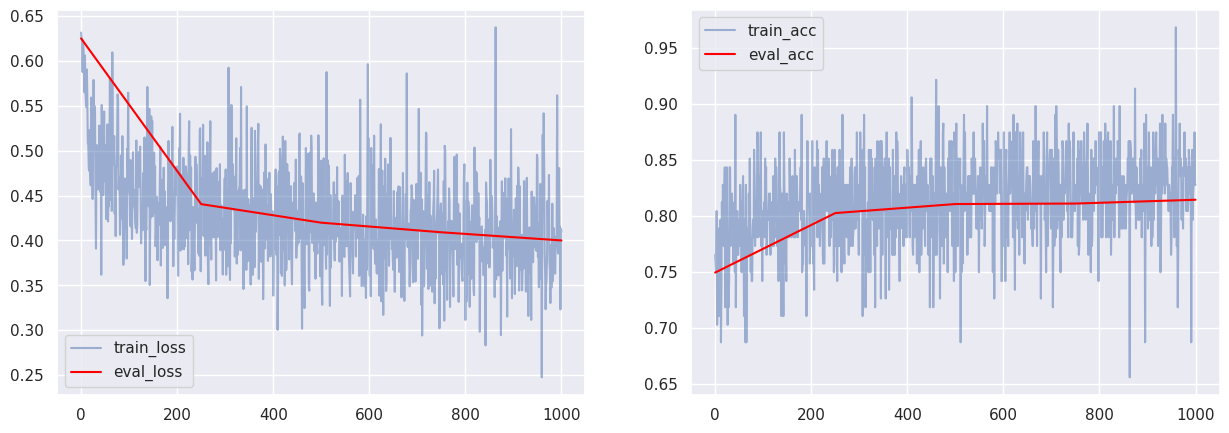

 25%|██▌       | 8/32 [00:34<01:44,  4.36s/it]

CPU times: user 9min 25s, sys: 2min 45s, total: 12min 11s
Wall time: 23min 32s


In [26]:
%%time
training_loop_fn(model, optimizer, 1000, 250, train_dataloader, eval_dataloader)

In [27]:
val_loss, val_acc, val_f1 = evaluate(model, eval_dataloader)
print(f'val loss: {val_loss}')
print(f'val accuracy: {val_acc}')
print(f'val f1_score: {val_f1}')


val loss: 0.4000400747398046
val accuracy: 0.8147833347320557
val f1_score: 0.5155555555555555


В моей интерпретации режим дообучения с размороженоой только частью весов классификации ожидаемо дал меньщий прирост в метриках по сравнению с полным fine-tuning методом. В используеммых данных не совсем корректно опираться на метрику точности так как присутсвует явный дисбаланс классов, однако по точности модель после дообучения классификатора выбивает метрку большую чем дефолтная модель, но по f мере ситуация хуже, метрика просела давольно сильно, на 0,15

In [16]:
peft_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    inference_mode=False,
    r=8,
    lora_alpha=32,
    lora_dropout=0.1,
    target_modules=["query", "key", "value", "dense"],
    modules_to_save=["classifier"],
    bias="none",
)

model = Model(tokenizer).to(device)
lora_model = get_peft_model(model, peft_config).to(device)
lora_model.print_trainable_parameters()

trainable params: 1,340,930 || all params: 164,792,068 || trainable%: 0.8137


In [17]:
optimizer = AdamW(lora_model.parameters(), lr=1e-4)

In [18]:
torch.cuda.empty_cache()

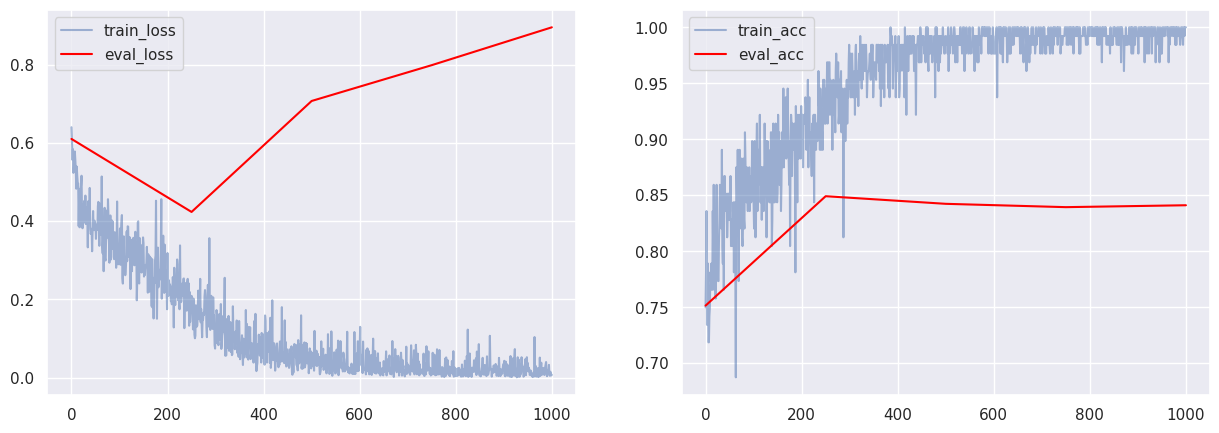

 25%|██▌       | 8/32 [00:37<01:53,  4.72s/it]

CPU times: user 11min 57s, sys: 2min 41s, total: 14min 38s
Wall time: 24min 36s


In [35]:
%%time
training_loop_fn(lora_model, optimizer, 1000, 250, train_dataloader, eval_dataloader)

In [36]:
val_loss, val_acc, val_f1 = evaluate(lora_model, eval_dataloader)
print(f'val loss: {val_loss}')
print(f'val accuracy: {val_acc}')
print(f'val f1_score: {val_f1}')

val loss: 0.8954843733405905
val accuracy: 0.84112149477005
val f1_score: 0.6792452830188679


При дообучении через лора адаптер удается добиться почти таких же метрик как и при полном дообучении всей модели. Также по графику лосса можно сделать вывод о том, что можно сократиить обучение в 4 раза и мы не потеряем в качестве, так как дальше модель явно переобучается. Давайте попробуем это сделать

In [35]:
peft_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    inference_mode=False,
    r=8,
    lora_alpha=32,
    lora_dropout=0.1,
    target_modules=["query", "key", "value", "dense"],
    modules_to_save=["classifier"],
    bias="none",
)

model = Model(tokenizer).to(device)
lora_model = get_peft_model(model, peft_config).to(device)
lora_model.print_trainable_parameters()

trainable params: 1,340,930 || all params: 164,792,068 || trainable%: 0.8137


In [36]:
optimizer = AdamW(lora_model.parameters(), lr=1e-4)

In [37]:
torch.cuda.empty_cache()

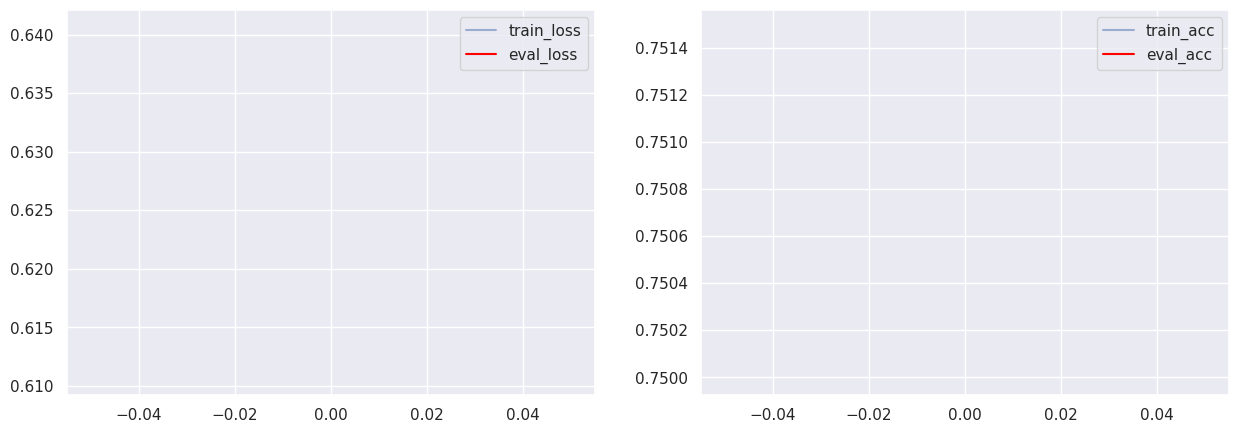

 25%|██▌       | 8/32 [00:41<02:03,  5.14s/it]

CPU times: user 3min 5s, sys: 44 s, total: 3min 49s
Wall time: 7min 1s


In [38]:
%%time
training_loop_fn(lora_model, optimizer, 200, 50, train_dataloader, eval_dataloader)

In [39]:
val_loss, val_acc, val_f1 = evaluate(lora_model, eval_dataloader)
print(f'val loss: {val_loss}')
print(f'val accuracy: {val_acc}')
print(f'val f1_score: {val_f1}')

val loss: 0.37449802862149534
val accuracy: 0.8530161380767822
val f1_score: 0.6899641577060932


По графикам динамики лоса видно что можно еще сократить время обучения без потери качества

По итогам проведенных тестов можно сделать вывод о том что выбранная модель вполне успешно может быть немного дообучена для решения задачи на классификации токсичного контента конкртеном датасете комментариев на русском языке. По итогам были получены следующие метрики (с учетом дисбаланса классов ориетироваться стоит больше на f1_score)
| Метод обучения       | Accuracy | F1-Score |
|----------------------|----------|----------|
| Default              | 0.731    | 0.651    |
| Fine-tuning          | 0,848    | 0,684    |
| Linear Probing       | 0,815    | 0,515    |
| LoRA                 | 0.853    | 0.689    |

Видно, что при использовании лора адаптера было получено наилучшее качество, которое перебило даже полное дообучение модели, что может быть вполне удивительно, наверное, параметры при полном дообучении были подобраны не совсем верно. Также стоит сравнить и полное время обучение всех 3 вариантов улучшения моделей

| Метод обучения       | Время
|----------------------|----------|
| Fine-tuning          | 18:28    |
| Linear Probing       | 12:11    |
| LoRA                 | 3:49     |

Стоит отметить также, что при использовании лора адаптера удалось сократить время обучения за счет сокращения количества эпох до достижения наилучшего качества, то есть модель сошлась сильно быстрее, чем при использовании других методов.